<a href="https://colab.research.google.com/github/dacdemon/ITD/blob/main/Practica_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 4: Miremos un poco a nuestro planeta.
##Alumno: Damián Coria
##Comisión: 2

# 1) Carga, limpieza, ajustes y primera visión de los datos.

In [ ]:
# Importamos las librerias necesarias para esta praactica (pandas, matplot y seaborn).

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos los archivos csv desde un repositorio web.

url1 = "https://raw.githubusercontent.com/dacdemon/ITD/refs/heads/main/life-expectancy.csv"
url2 = "https://raw.githubusercontent.com/dacdemon/ITD/refs/heads/main/happiness-vs-gdp-per-capita-time.csv"
df_vida = pd.read_csv(url1)
df_pbi = pd.read_csv(url2)

# Se le da un vistazo a cada DataFrame.

In [ ]:
def analizar_dataframe(df):
    print("Primeras filas:")
    display(df.head())

    print("\nDimensiones:")
    dimensiones = df.shape
    print(dimensiones[0] ,"Filas")
    print(dimensiones[1], "columnas")

    print("\nTipos de datos:")
    print(df.dtypes)
analizar_dataframe(df_pbi)
analizar_dataframe(df_vida)

Primeras filas:


,Entity,Code,Year,Happiness: Happy (aggregate),1076736-annotations,"GDP per capita, PPP (constant 2021 international $)",Population (historical),World regions according to OWID
0,Afghanistan,AFG,2000,NaN,NaN,1617.8264,20130334.0,NaN
1,Afghanistan,AFG,2001,NaN,NaN,1454.1108,20284303.0,NaN
2,Afghanistan,AFG,2002,NaN,NaN,1774.3087,21378123.0,NaN
3,Afghanistan,AFG,2003,NaN,NaN,1815.9282,22733053.0,NaN
4,Afghanistan,AFG,2004,NaN,NaN,1776.9182,23560656.0,NaN



Dimensiones:
59300 Filas
8 columnas

Tipos de datos:
Entity                                                  object
Code                                                    object
Year                                                     int64
Happiness: Happy (aggregate)                           float64
1076736-annotations                                     object
GDP per capita, PPP (constant 2021 international $)    float64
Population (historical)                                float64
World regions according to OWID                         object
dtype: object
Primeras filas:


,Entity,Code,Year,Period life expectancy at birth
0,Afghanistan,AFG,1950,28.1563
1,Afghanistan,AFG,1951,28.5836
2,Afghanistan,AFG,1952,29.0138
3,Afghanistan,AFG,1953,29.4521
4,Afghanistan,AFG,1954,29.6975



Dimensiones:
21565 Filas
4 columnas

Tipos de datos:
Entity                              object
Code                                object
Year                                 int64
Period life expectancy at birth    float64
dtype: object


# Análisis de calidad de los datos

##Creamos una función para analizar la calidad de ambos DataFrames, verificando valores faltantes y registros duplicados ya que con el análisis anterior con "df.dtypes" se concluye que los tipos de datos son coherentes.

In [ ]:
def analizar_calidad(df):
    print("Valores faltantes:")
    display(df.isnull().sum().to_frame("Faltantes"))

    print("\nFilas duplicadas:")
    print(df.duplicated().sum())


analizar_calidad(df_pbi)
analizar_calidad(df_vida)


Valores faltantes:


,Faltantes
Entity,0
Code,3780
Year,0
Happiness: Happy (aggregate),58875
1076736-annotations,59295
"GDP per capita, PPP (constant 2021 international $)",52064
Population (historical),476
World regions according to OWID,59028



Filas duplicadas:
0
Valores faltantes:


,Faltantes
Entity,0
Code,1956
Year,0
Period life expectancy at birth,0



Filas duplicadas:
0


# Hasta acá tenemos dos conclusiones: No hay filas duplicadas y los tipos de datos son correctos.
##Pero se observa una gran cantidad de faltantes.
###Importante: No deberíamos reemplazar los 52.064 valores faltantes del PBI con moda o mediana, porque estaríamos inventando valores para países y años donde no tenemos información.

# Se procede a la limpieza de los dataset eliminando columnas que no son necesarias para esta práctica.

# Limpieza del dataset de PBI

##El dataset contiene variables que no son necesarias para los objetivos de esta práctica y presentan una gran cantidad de valores faltantes.

##Por este motivo, conservamos únicamente las variables correspondientes al país, año y PBI per cápita.

In [ ]:
df_pbi = df_pbi[["Entity", "Year", "GDP per capita, PPP (constant 2021 international $)"]].copy()
# Renombramos la columna para una lectura mas simple
df_pbi = df_pbi.rename(columns={"GDP per capita, PPP (constant 2021 international $)": "PBI_per_capita"})
# Buscamos faltantes y los eliminamos
display(df_pbi.isnull().sum().to_frame("Faltantes"))
df_pbi = df_pbi.dropna(subset=["PBI_per_capita"])
display(df_pbi.isnull().sum().to_frame("Faltantes"))

,Faltantes
Entity,0
Year,0
PBI_per_capita,52064


,Faltantes
Entity,0
Year,0
PBI_per_capita,0


### Limpieza del dataset de expectativa de vida

Para este análisis conservamos únicamente las variables correspondientes al país, año y expectativa de vida.

La columna "Code" no será necesaria para los análisis posteriores, por lo que no se incorpora al DataFrame.

In [ ]:
df_vida = df_vida[["Entity", "Year", "Period life expectancy at birth"]].copy()
# Renombramos la columna para una lectura mas simple
df_vida = df_vida.rename(columns={"Period life expectancy at birth": "Expectativa_vida"})
display(df_vida.isnull().sum().to_frame("Faltantes"))

,Faltantes
Entity,0
Year,0
Expectativa_vida,0


# Conclusión de la limpieza

##Se eliminaron las columnas que no serán necesarias para el análisis y los registros sin información de PBI per cápita.
##Los DataFrames finales no presentan valores faltantes ni registros duplicados y sus tipos de datos son correctos.

# 2) Análisis de series temporales

## Analizamos la evolución del PBI per cápita de Argentina y la comparamos con Brasil, Chile y Uruguay.
## Además, incorporamos a Alemania como referencia europea para observar las diferencias respecto de los países de la región.

In [ ]:
# Creamos una función que permite seleccionar los países que queremos comparar en el análisis.
def seleccionar_paises(df, paises):
    df_seleccion = df[df["Entity"].isin(paises)].copy()

    return df_seleccion
paises = ["Argentina", "Brazil", "Chile", "Uruguay", "Germany"]
df_paises = seleccionar_paises(df_pbi, paises)

# Chequeamos que la función seleccionó correctamente los cinco países.
display(df_paises["Entity"].value_counts())

,count
Entity,
Argentina,35
Brazil,35
Chile,35
Germany,35
Uruguay,35


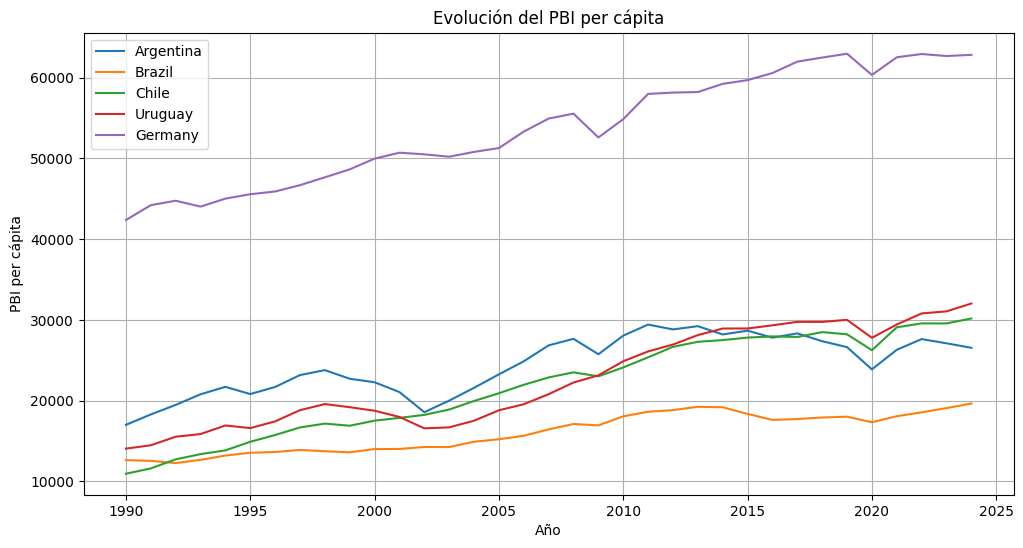

In [ ]:
plt.figure(figsize=(12, 6))

for pais in paises:
    datos_pais = df_paises[df_paises["Entity"] == pais]
# Los datos no estaban ordenados cronologicamente por lo que utilizamos "sort_values" para evitar errores en el grafico
    datos_pais = datos_pais.sort_values("Year")
    plt.plot(datos_pais["Year"], datos_pais["PBI_per_capita"], label=pais)

plt.title("Evolución del PBI per cápita")
plt.xlabel("Año")
plt.ylabel("PBI per cápita")
plt.legend()
plt.grid()
plt.show()

# Análisis

###Todos los países muestran una tendencia general de crecimiento. Argentina presenta mayor variación con caídas importantes, mientras que Chile y Uruguay muestran un crecimiento más sostenido.
###Como contexto se toma como referencia un país europeo como Alemania que presenta un PBI per cápita considerablemente superior durante todo el período analizado.


# Comparación de países mediante Pivot

## Reorganizamos los datos colocando los años como índices y los países como columnas para facilitar la comparación del PBI per cápita.


In [ ]:
df_pivot = df_paises.pivot(index="Year", columns="Entity", values="PBI_per_capita")
# visualizamos si se aplicaron los cambios:
display(df_pivot.head())

Entity,Argentina,Brazil,Chile,Germany,Uruguay
Year,,,,,
1990,17007.285,12633.288,10952.655,42373.530,14060.846
1991,18295.610,12546.561,11607.530,44214.754,14474.732
1992,19476.283,12271.979,12735.602,44763.664,15536.487
1993,20791.346,12669.429,13377.306,44037.523,15865.277
1994,21711.844,13202.931,13846.349,45024.992,16932.030


# Correlación del PBI entre países
##Calculamos la correlación entre la evolución del PBI per cápita de Argentina y la de los demás países seleccionados.

In [ ]:
# Se utiliza .drop Argentina para que no aparesca en nuestro grafico

correlacion_argentina = df_pivot.corr()["Argentina"].drop("Argentina")
display(correlacion_argentina.to_frame("Correlación con Argentina"))

,Correlación con Argentina
Entity,
Brazil,0.910474
Chile,0.880379
Germany,0.835268
Uruguay,0.867404


# Mapa de calor de correlaciones en Latinoamérica
## Seleccionamos los países de Latinoamérica presentes en el dataset y analizamos la correlación de la evolución del PBI per cápita entre ellos mediante un mapa de calor.

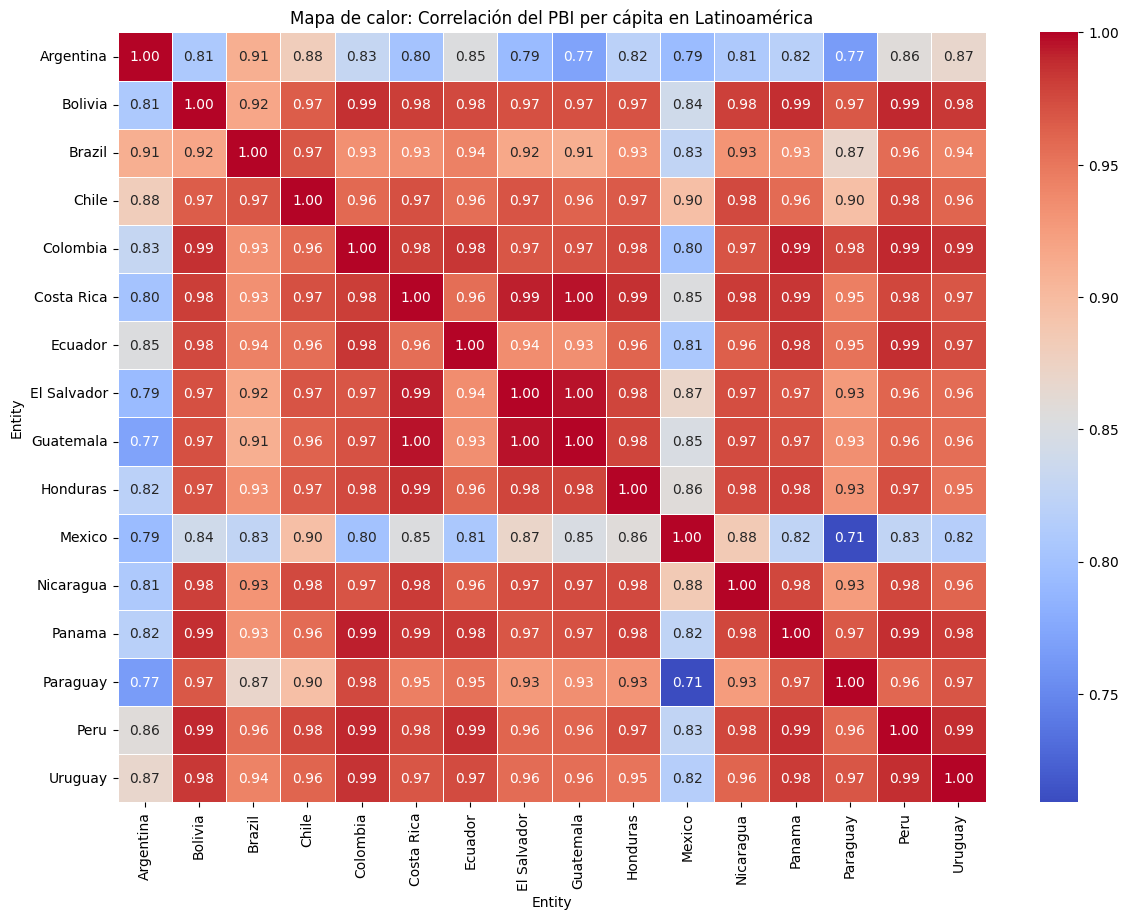

In [ ]:
paises_latinoamerica = ["Argentina", "Bolivia", "Brazil", "Chile", "Colombia",
    "Costa Rica", "Ecuador", "El Salvador", "Guatemala", "Honduras", "Mexico",
    "Nicaragua", "Panama", "Paraguay", "Peru", "Uruguay"]
# Dato: si algun pais no existe en mi dataset "isin" continua con el proximo.
df_latinoamerica = df_pbi[df_pbi["Entity"].isin(paises_latinoamerica)].copy()
df_pivot_latinoamerica = df_latinoamerica.pivot(
    index="Year",
    columns="Entity",
    values="PBI_per_capita")

matriz_correlacion_latinoamerica = df_pivot_latinoamerica.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(matriz_correlacion_latinoamerica,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5)
plt.title("Mapa de calor: Correlación del PBI per cápita en Latinoamérica")
plt.show()

# Análisis del mapa de calor

##Argentina presenta correlaciones positivas con todos los países latinoamericanos analizados, aunque en general son menores que las observadas entre los demás países.

##La mayor correlación de Argentina es con Brasil (0,91), mientras que las menores se observan con Guatemala y Paraguay (0,77).

##Esto indica que la evolución del PBI per cápita de Argentina sigue una tendencia similar a la región, pero presenta un comportamiento más variable y menos sincronizado con varios países latinoamericanos.

# 3. Unión de los datasets
##Unimos los datos de PBI per cápita y expectativa de vida utilizando como referencia el país y el año.
##Conservamos únicamente aquellos registros que tengan información disponible en ambos datasets.

In [ ]:
# Vemos el tamaño antes del merge
print("Tamaño del dataset de PBI:")
print(df_pbi.shape)
print("\nTamaño del dataset de expectativa de vida:")
print(df_vida.shape)

Tamaño del dataset de PBI:
(7236, 3)

Tamaño del dataset de expectativa de vida:
(21565, 3)


In [ ]:
# Realizamos el merge
df_final = pd.merge(df_pbi, df_vida, on=["Entity", "Year"], how="inner")
# Vemos el resultado
print("Tamaño después del merge:")
print(df_final.shape)

display(df_final.head())

Tamaño después del merge:
(6767, 4)


,Entity,Year,PBI_per_capita,Expectativa_vida
0,Afghanistan,2000,1617.8264,55.0047
1,Afghanistan,2001,1454.1108,55.5113
2,Afghanistan,2002,1774.3087,56.2251
3,Afghanistan,2003,1815.9282,57.1713
4,Afghanistan,2004,1776.9182,57.8098


# Análisis

##Luego del merge se obtuvieron 6.767 registros con información disponible tanto de PBI per cápita como de expectativa de vida.
##La mayor parte de los datos de PBI pudo conservarse, mientras que una gran cantidad de registros del dataset de expectativa de vida quedó fuera por no tener una coincidencia de país y año en el dataset de PBI.

# 4. PBI y expectativa de vida
## Analizamos la relación entre el PBI per cápita y la expectativa de vida, comenzando por Argentina.

In [ ]:
df_argentina = df_final[df_final["Entity"] == "Argentina"].copy()
correlacion = df_argentina["PBI_per_capita"].corr(df_argentina["Expectativa_vida"])
print("Correlación entre PBI y expectativa de vida en Argentina:")
print(round(correlacion, 2))

Correlación entre PBI y expectativa de vida en Argentina:
0.83


# Análisis
## La correlación de 0,83 indica una relación positiva fuerte entre el PBI per cápita y la expectativa de vida en Argentina.

In [ ]:
# Ahora hagamos el scatterplot para comprobar visualmente esa relación:

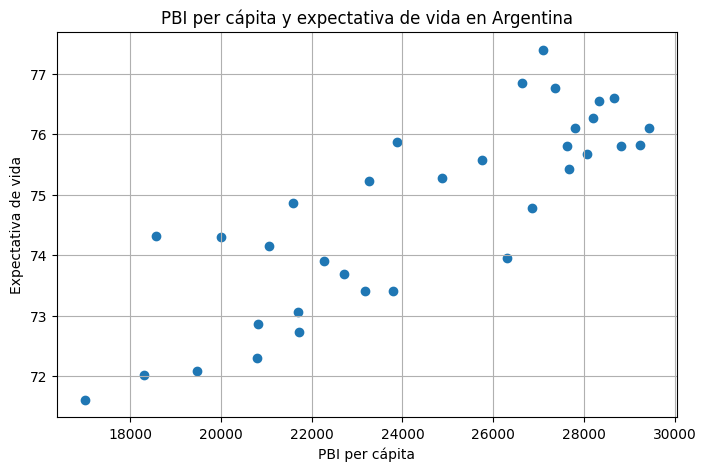

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df_argentina["PBI_per_capita"],
    df_argentina["Expectativa_vida"])
plt.title("PBI per cápita y expectativa de vida en Argentina")
plt.xlabel("PBI per cápita")
plt.ylabel("Expectativa de vida")
plt.grid()

plt.show()

# Análisis del gráfico
## El scatterplot muestra una tendencia ascendente: a mayores valores de PBI per cápita, generalmente se observa una mayor expectativa de vida.

In [ ]:
def analizar_pais(df, pais):
    datos_pais = df[df["Entity"] == pais]

    pearson = datos_pais["PBI_per_capita"].corr(
        datos_pais["Expectativa_vida"]
    )

    print(pais, "- Pearson:", round(pearson, 2))

    plt.figure(figsize=(8, 5))

    plt.scatter(
        datos_pais["PBI_per_capita"],
        datos_pais["Expectativa_vida"]
    )

    plt.title("PBI per cápita y expectativa de vida - " + pais)
    plt.xlabel("PBI per cápita")
    plt.ylabel("Expectativa de vida")
    plt.grid()

    plt.show()

Argentina - Pearson: 0.83


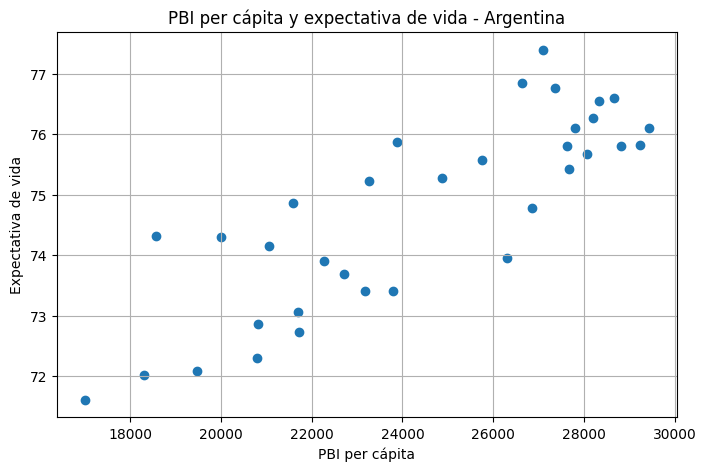

Brazil - Pearson: 0.96


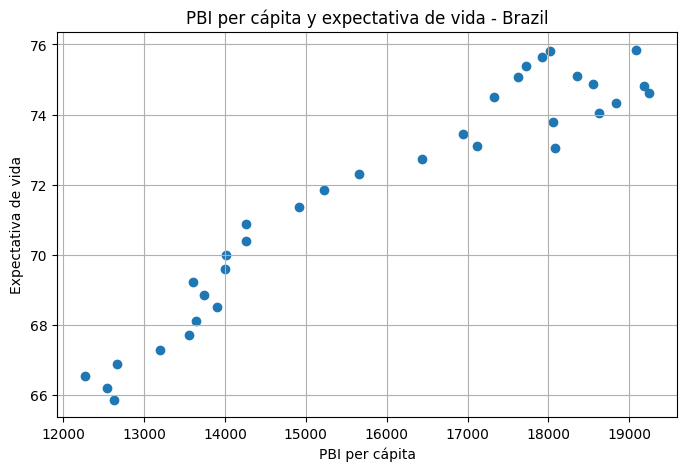

Chile - Pearson: 0.96


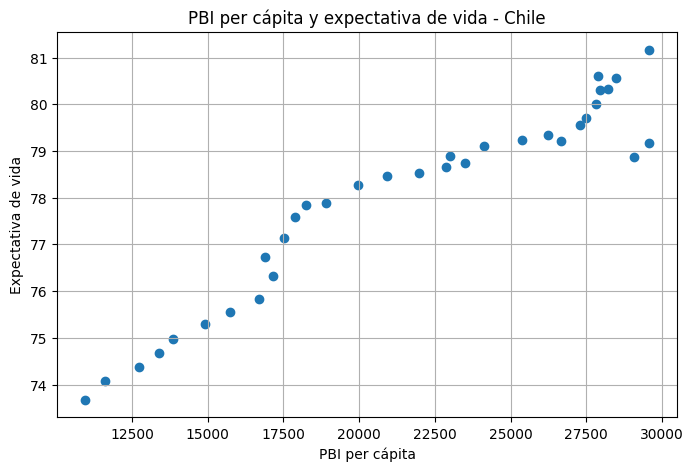

Uruguay - Pearson: 0.88


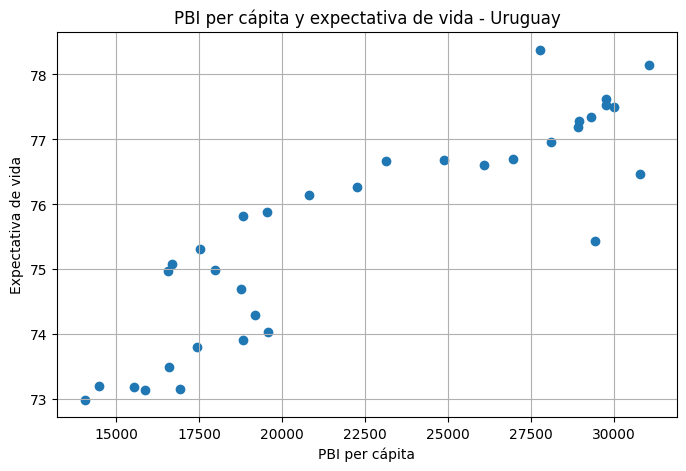

Germany - Pearson: 0.96


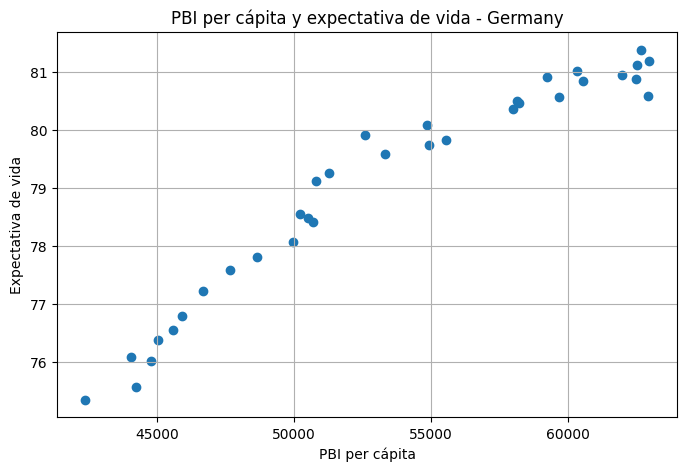

In [ ]:
for pais in paises:
    analizar_pais(df_final, pais)

# Conclusiones

Argentina: Pearson de 0,83. Presenta una correlación positiva fuerte, aunque el scatterplot muestra mayor dispersión que en otros países.

Brasil: Pearson de 0,96. Presenta una correlación positiva muy fuerte y una clara tendencia ascendente.

Chile: Pearson de 0,96. Presenta una correlación positiva muy fuerte y una clara tendencia ascendente.

Uruguay: Pearson de 0,88. Presenta una correlación positiva fuerte, aunque con cierta dispersión en los datos.

Alemania: Pearson de 0,96. Presenta una correlación positiva muy fuerte y una clara tendencia ascendente.

En general, en todos los países analizados se observa que un mayor PBI per cápita está asociado con una mayor expectativa de vida.

# Análisis de PBI y expectativa de vida en 2020

## Seleccionamos todos los países con información disponible en 2020 y analizamos la relación entre el PBI per cápita y la expectativa de vida.


In [ ]:
# Filtramos el año 2020
df_2020 = df_final[df_final["Year"] == 2020].copy()

print("Cantidad de registros en 2020:")
print(df_2020.shape[0])

Cantidad de registros en 2020:
204


Pearson 2020: 0.74


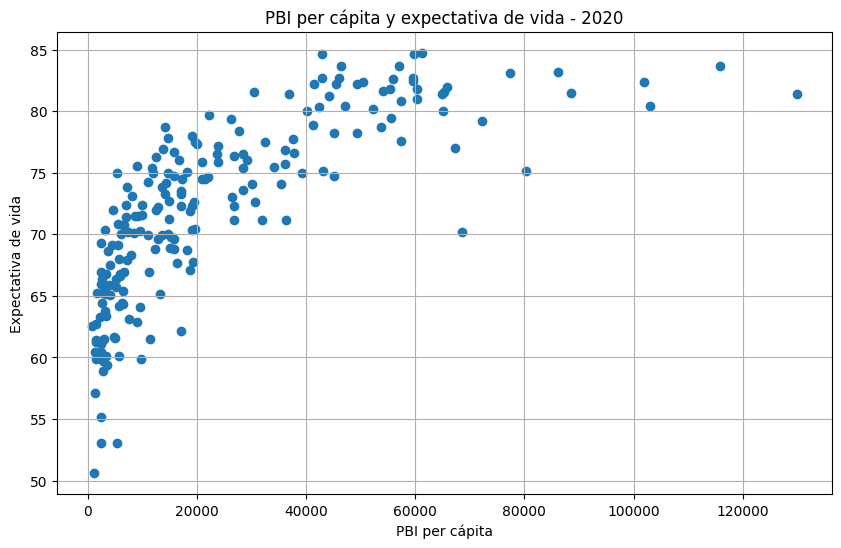

In [ ]:
pearson_2020 = df_2020["PBI_per_capita"].corr(df_2020["Expectativa_vida"])
print("Pearson 2020:", round(pearson_2020, 2))
plt.figure(figsize=(10, 6))
plt.scatter(df_2020["PBI_per_capita"], df_2020["Expectativa_vida"])
plt.title("PBI per cápita y expectativa de vida - 2020")
plt.xlabel("PBI per cápita")
plt.ylabel("Expectativa de vida")
plt.grid()
plt.show()

# Análisis del año 2020

## Para el conjunto de países en 2020 se obtiene un Pearson de 0,74, indicando una correlación positiva fuerte.

##El scatterplot confirma la tendencia: los países con mayor PBI per cápita tienden a presentar una mayor expectativa de vida, aunque existe una dispersión considerable entre los datos.
##Tanto en la evolución individual de los países seleccionados como en la comparación global de 2020 se observa una relación positiva entre el PBI per cápita y la expectativa de vida.

# Conclusión final

##A lo largo de esta práctica se realizó la limpieza, transformación y combinación de datos de PBI per cápita y expectativa de vida, permitiendo analizar su comportamiento tanto a través del tiempo como entre distintos países.

##El análisis temporal mostró una tendencia general de crecimiento del PBI per cápita, aunque Argentina presentó mayores fluctuaciones que otros países de la región. El mapa de calor confirmó que Argentina mantiene correlaciones positivas con los países latinoamericanos analizados, pero con valores generalmente menores que los observados entre otros países de la región.

##Finalmente, al relacionar PBI per cápita y expectativa de vida se encontraron correlaciones positivas fuertes. Tanto en la evolución individual de los países como en la comparación global de 2020, los resultados indican que mayores niveles de PBI per cápita tienden a estar asociados con una mayor expectativa de vida.